In [1]:
# Cell 1 — ACLED Violence: user inputs, hazard definition, and run identifiers
# Pattern mirrors the SPEI / Extreme Heat notebooks.
#
# User inputs:
#   - ISO3: country code
#   - AS_OF_DATE: reference end date (YYYY-MM-DD, inclusive)
#   - LOOKBACK_MONTHS: window length in months
#
# Hazard definition (ACLED violence proximity exposure):
#   - Metric: violent events as point locations (ACLED)
#   - Time window: last LOOKBACK_MONTHS up to AS_OF_DATE (inclusive)
#   - Exposure rule: population is "affected" if they live within the ACLED buffer radius
#     of at least one event within the window (any-event exceedance).
#   - Buffer radii: ACLED standard 1 km / 2 km / 5 km (best estimate varies by event type / fatalities)
#   - Output: binary hazard impact mask (1 affected, 0 not) aligned to WorldPop 100 m grid.

from __future__ import annotations

from pathlib import Path
from datetime import date
import json
import pandas as pd

# -----------------------
# USER INPUTS
# -----------------------
ISO3 = "SDN"  # <- set per run
AS_OF_DATE = "2025-11-30"  # <- YYYY-MM-DD (inclusive end date)
LOOKBACK_MONTHS = 12  # window length (months)

AS_OF_DT = pd.to_datetime(AS_OF_DATE)

# -----------------------
# WINDOW (daily, inclusive)
# -----------------------
# Keep naming consistent with other hazards:
#   <ISO3>_<start>_<end>_m<months>
WINDOW_END = AS_OF_DT
WINDOW_START = (AS_OF_DT - pd.DateOffset(months=LOOKBACK_MONTHS)) + pd.Timedelta(days=1)

WINDOW_START_DATE = WINDOW_START.date().isoformat()
WINDOW_END_DATE = WINDOW_END.date().isoformat()

# -----------------------
# RUN IDENTIFIER
# -----------------------
RUN_ID = (
    f"{ISO3}_{WINDOW_START_DATE}_{WINDOW_END_DATE}_m{LOOKBACK_MONTHS}_acled_violence"
)

print("ISO3:", ISO3)
print("AS_OF_DATE:", AS_OF_DATE)
print("Window:", f"{WINDOW_START_DATE} → {WINDOW_END_DATE}", f"(m{LOOKBACK_MONTHS})")
print("Run ID:", RUN_ID)

# -----------------------
# Persist minimal run config (used later for QC PDF cover + metadata)
# -----------------------
run_config = {
    "iso3": ISO3,
    "as_of_date": AS_OF_DATE,
    "window_start_date": WINDOW_START_DATE,
    "window_end_date": WINDOW_END_DATE,
    "lookback_months": LOOKBACK_MONTHS,
    "hazard": "violence_acled_proximity",
    "notes": {
        "metric": "ACLED event points with ACLED-standard buffer radii (1/2/5 km)",
        "exposure_rule": "any-event within window (union of buffers; no double counting)",
        "baseline_relative_threshold": False,
        "consecutive_days_required": False,
    },
}

# Set these now; file paths and directories will be defined in the next cell.
RUN_METADATA = {"run_config": run_config}

ISO3: SDN
AS_OF_DATE: 2025-11-30
Window: 2024-12-01 → 2025-11-30 (m12)
Run ID: SDN_2024-12-01_2025-11-30_m12_acled_violence


In [3]:
# Cell 2 — Paths + directories (mirror SPEI pipeline layout)
# Defines canonical input paths and output/QC directories, plus standard filenames.

from pathlib import Path

# -----------------------
# INPUT PATHS
# -----------------------
WORLDPOP_TIF = Path("./population/sdn_pop_2025_CN_100m_R2025A_v1.tif")
ACLED_CSV = Path("./events/ACLED Data_2026-01-30.csv")
COD_GDB_ZIP = Path("../COD/global_admin_boundaries_matched_latest.gdb.zip")

# -----------------------
# OUTPUT BASE DIRS
# -----------------------
BASE_OUT_DIR = Path("../outputs/acled_violent_events")  # adjust if your SPEI pipeline uses a different root
RUN_DIR = BASE_OUT_DIR / RUN_ID

DIRS = {
    "run": RUN_DIR,
    "data": RUN_DIR / "data",
    "intermediate": RUN_DIR / "intermediate",
    "results": RUN_DIR / "results",
    "qc": RUN_DIR / "qc",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

# -----------------------
# STANDARD OUTPUT FILENAMES
# -----------------------
# Raster outputs (aligned to WorldPop grid)
VIOL_MASK_TIF = (
    DIRS["results"] / f"{RUN_ID}_violence_mask.tif"
)  # uint8: 1 affected, 0 otherwise
VIOL_POP_AFFECTED_TIF = (
    DIRS["results"] / f"{RUN_ID}_violence_pop_affected.tif"
)  # float32: WorldPop * mask

# Admin outputs
ADM2_STATS_CSV = DIRS["results"] / f"{RUN_ID}_adm2_stats.csv"

# Vector QA (optional but useful)
VIOL_FOOTPRINT_GPKG = DIRS["intermediate"] / f"{RUN_ID}_violence_footprint.gpkg"

# QC plots
QC_EVENTS_PNG = DIRS["qc"] / f"{RUN_ID}_events_points.png"
QC_FOOTPRINT_PNG = DIRS["qc"] / f"{RUN_ID}_footprint_preview.png"
QC_MASK_PNG = DIRS["qc"] / f"{RUN_ID}_mask_overlay.png"
QC_ADM2_MAP_PNG = DIRS["qc"] / f"{RUN_ID}_adm2_pct_affected.png"

# Run metadata file (written now, appended later)
RUN_METADATA_PATH = DIRS["run"] / "run_metadata.json"

# -----------------------
# Basic checks
# -----------------------
for pth in [WORLDPOP_TIF, ACLED_CSV, COD_GDB_ZIP]:
    if not pth.exists():
        raise FileNotFoundError(f"Missing input: {pth.resolve()}")

print("Run directory:", DIRS["run"].resolve())
print("WorldPop:", WORLDPOP_TIF.resolve())
print("ACLED CSV:", ACLED_CSV.resolve())
print("COD GDB zip:", COD_GDB_ZIP.resolve())

# Persist initial run metadata (append to this dict in later cells)
RUN_METADATA["paths"] = {
    "worldpop_tif": str(WORLDPOP_TIF),
    "acled_csv": str(ACLED_CSV),
    "cod_gdb_zip": str(COD_GDB_ZIP),
    "outputs_root": str(BASE_OUT_DIR),
    "run_dir": str(DIRS["run"]),
    "dirs": {k: str(v) for k, v in DIRS.items()},
}

import json

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Wrote:", RUN_METADATA_PATH.name)

Run directory: /Users/jamesebrown/Library/Mobile Documents/com~apple~CloudDocs/Code/WIA/outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence
WorldPop: /Users/jamesebrown/Library/Mobile Documents/com~apple~CloudDocs/Code/WIA/ACLED-Violence/population/sdn_pop_2025_CN_100m_R2025A_v1.tif
ACLED CSV: /Users/jamesebrown/Library/Mobile Documents/com~apple~CloudDocs/Code/WIA/ACLED-Violence/events/ACLED Data_2026-01-30.csv
COD GDB zip: /Users/jamesebrown/Library/Mobile Documents/com~apple~CloudDocs/Code/WIA/COD/global_admin_boundaries_matched_latest.gdb.zip
Wrote: run_metadata.json


In [4]:
# Cell 3 — Load WorldPop grid + core raster metadata (reference grid)
# Mirrors the "reference raster" pattern used in other hazard pipelines:
# - Establish CRS, transform, shape, nodata, dtype
# - Store key metadata in RUN_METADATA for reproducibility/QC

import rasterio

with rasterio.open(WORLDPOP_TIF) as src:
    WP_PROFILE = src.profile.copy()
    WP_CRS = src.crs
    WP_TRANSFORM = src.transform
    WP_HEIGHT, WP_WIDTH = src.height, src.width
    WP_NODATA = src.nodata
    WP_DTYPE = src.dtypes[0]
    WP_BOUNDS = src.bounds
    WP_RES = src.res  # (xres, yres)

print("WorldPop reference grid")
print("  CRS:", WP_CRS)
print("  Shape (H, W):", (WP_HEIGHT, WP_WIDTH))
print("  Resolution:", WP_RES)
print("  Nodata:", WP_NODATA)
print("  Dtype:", WP_DTYPE)
print("  Bounds:", WP_BOUNDS)

# Persist to metadata
RUN_METADATA["worldpop_ref"] = {
    "crs": str(WP_CRS),
    "shape": [int(WP_HEIGHT), int(WP_WIDTH)],
    "res": [float(WP_RES[0]), float(WP_RES[1])],
    "nodata": None if WP_NODATA is None else float(WP_NODATA),
    "dtype": str(WP_DTYPE),
    "bounds": [
        float(WP_BOUNDS.left),
        float(WP_BOUNDS.bottom),
        float(WP_BOUNDS.right),
        float(WP_BOUNDS.top),
    ],
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)

WorldPop reference grid
  CRS: EPSG:4326
  Shape (H, W): (16252, 20438)
  Resolution: (0.00083333333, 0.00083333333)
  Nodata: -99999.0
  Dtype: float32
  Bounds: BoundingBox(left=21.814999192739997, bottom=8.681666967939991, right=38.846665791279996, top=22.22500024709999)
Updated: run_metadata.json


In [5]:
# Cell 4 — Load + filter ACLED events (window + supported types)
# Outputs:
#   - acled_df: filtered pandas DataFrame
#   - QC: counts by event_type and by buffer_km (ACLED radii 1/2/5 km)

import pandas as pd
import numpy as np

# -----------------------
# ACLED column names (expected)
# -----------------------
LAT_COL, LON_COL = "latitude", "longitude"
DATE_COL = "event_date"
TYPE_COL = "event_type"
FATAL_COL = "fatalities"

# Supported ACLED event types for this indicator (no default buffer)
ACLED_TYPES_ALLOWED = {
    "Battles",
    "Explosions/Remote violence",
    "Violence against civilians",
    "Riots",
    "Protests",
}

# -----------------------
# Load
# -----------------------
raw_df = pd.read_csv(ACLED_CSV)

required = [LAT_COL, LON_COL, DATE_COL, TYPE_COL]
missing = [c for c in required if c not in raw_df.columns]
if missing:
    raise ValueError(
        f"Missing required columns: {missing}. Found: {list(raw_df.columns)}"
    )

df = raw_df.copy()

# Parse + clean key fields
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[LAT_COL] = pd.to_numeric(df[LAT_COL], errors="coerce")
df[LON_COL] = pd.to_numeric(df[LON_COL], errors="coerce")

df = df.dropna(subset=[DATE_COL, LAT_COL, LON_COL, TYPE_COL]).copy()
df = df[df[LAT_COL].between(-90, 90) & df[LON_COL].between(-180, 180)].copy()

# Fatalities (if absent, assume 0)
if FATAL_COL in df.columns:
    df[FATAL_COL] = pd.to_numeric(df[FATAL_COL], errors="coerce").fillna(0)
else:
    df[FATAL_COL] = 0

# -----------------------
# Filter to time window (inclusive)
# -----------------------
df = df[(df[DATE_COL] >= WINDOW_START) & (df[DATE_COL] <= WINDOW_END)].copy()

# -----------------------
# Filter to supported event types (avoid default buffers)
# -----------------------
df = df[df[TYPE_COL].isin(ACLED_TYPES_ALLOWED)].copy()

if df.empty:
    raise ValueError(
        "No ACLED events remain after filtering to window + supported event types."
    )


# -----------------------
# ACLED radii mapping (1/2/5 km only)
# -----------------------
def acled_best_radius_km(event_type: str, fatalities: float) -> int:
    if event_type == "Battles":
        return 5
    if event_type == "Explosions/Remote violence":
        return 5
    if event_type == "Violence against civilians":
        return 5 if fatalities >= 1 else 2
    if event_type == "Riots":
        return 2
    if event_type == "Protests":
        return 1
    # Should never happen due to filtering
    raise ValueError(f"Unexpected event_type after filtering: {event_type}")


df["buffer_km"] = [
    acled_best_radius_km(t, f) for t, f in zip(df[TYPE_COL], df[FATAL_COL])
]

acled_df = df  # final filtered dataset

# -----------------------
# QC summaries
# -----------------------
print(f"ACLED events after filtering: {len(acled_df):,}")
print(f"Window: {WINDOW_START_DATE} → {WINDOW_END_DATE} (inclusive)")
print("\nEvent types:")
display(acled_df[TYPE_COL].value_counts())

print("\nBuffer radii (km):")
display(acled_df["buffer_km"].value_counts().sort_index())

# Persist basic event stats to metadata
RUN_METADATA["acled_events"] = {
    "rows_loaded": int(len(raw_df)),
    "rows_after_filter": int(len(acled_df)),
    "window_start": WINDOW_START_DATE,
    "window_end": WINDOW_END_DATE,
    "event_type_counts": acled_df[TYPE_COL].value_counts().to_dict(),
    "buffer_km_counts": acled_df["buffer_km"].value_counts().sort_index().to_dict(),
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("\nUpdated:", RUN_METADATA_PATH.name)

ACLED events after filtering: 4,307
Window: 2024-12-01 → 2025-11-30 (inclusive)

Event types:


event_type
Explosions/Remote violence    1437
Battles                       1406
Violence against civilians    1323
Protests                       129
Riots                           12
Name: count, dtype: int64


Buffer radii (km):


buffer_km
1     129
2     597
5    3581
Name: count, dtype: int64


Updated: run_metadata.json


Events bounds (WGS84): [22.133   9.4341 37.7294 21.9913]
Using ADM2 layer: admin2
Loaded admin2 features for SDN: 188
CRS: EPSG:4326
Example adm2_pcode: SD07090


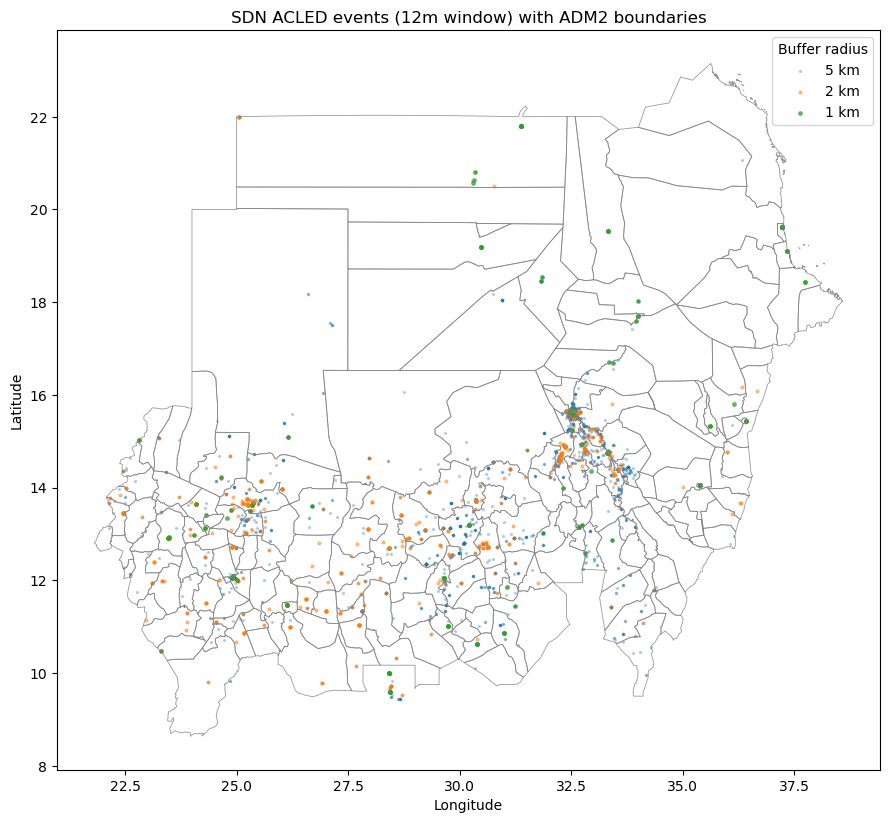

Saved QC: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/qc/SDN_2024-12-01_2025-11-30_m12_acled_violence_events_points.png


In [9]:
# Cell 5 — Event points GeoDataFrame + QC map with ADM2 boundaries
# Outputs:
#   - events_wgs84: GeoDataFrame in EPSG:4326
#   - QC PNG saved to QC_EVENTS_PNG

import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import fiona

# -----------------------
# Build events GeoDataFrame (WGS84)
# -----------------------
events_wgs84 = gpd.GeoDataFrame(
    acled_df.copy(),
    geometry=[Point(xy) for xy in zip(acled_df[LON_COL], acled_df[LAT_COL])],
    crs="EPSG:4326",
)

print("Events bounds (WGS84):", events_wgs84.total_bounds)

# -----------------------
# Load ADM2 boundaries from zipped COD GDB
# -----------------------
gdb_vsi_path = f"zip://{COD_GDB_ZIP.resolve()}"
ADM2_LAYER = "admin2"
print("Using ADM2 layer:", ADM2_LAYER)
admin2_gdf = gpd.read_file(gdb_vsi_path, layer=ADM2_LAYER)

# Basic schema checks
required_cols = {"iso3", "adm2_pcode", "geometry"}
missing = required_cols - set(admin2_gdf.columns)
if missing:
    raise KeyError(
        f"Missing required columns in COD admin2: {missing}. Available: {list(admin2_gdf.columns)}"
    )

# Filter to country
admin2_gdf = admin2_gdf[admin2_gdf["iso3"] == ISO3].copy()
admin2_gdf = admin2_gdf.dropna(subset=["adm2_pcode", "geometry"]).reset_index(drop=True)

if admin2_gdf.empty:
    raise ValueError(
        f"No admin2 features found for ISO3={ISO3} in {COD_GDB_ZIP} layer={ADM2_LAYER}"
    )

# Ensure valid geometries and reproject to WGS84
admin2_gdf = admin2_gdf.to_crs("EPSG:4326")

admin2_gdf["geometry"] = admin2_gdf["geometry"].buffer(0)
admin2_gdf = admin2_gdf[admin2_gdf.is_valid].copy()

print(f"Loaded admin2 features for {ISO3}: {len(admin2_gdf):,}")
print("CRS:", admin2_gdf.crs)
print("Example adm2_pcode:", admin2_gdf["adm2_pcode"].iloc[0])


# -----------------------
# QC plot: ADM2 boundaries + events
# -----------------------
fig, ax = plt.subplots(figsize=(9, 9))

# Plot ADM2 first (light outlines)
admin2_gdf.boundary.plot(
    ax=ax,
    linewidth=0.6,
    edgecolor="grey",
    alpha=0.8,
)

# Plot events, ordered by buffer size
for km, ms, a in [(5, 2, 0.25), (2, 4, 0.45), (1, 6, 0.65)]:
    subset = events_wgs84[events_wgs84["buffer_km"] == km]
    if not subset.empty:
        subset.plot(ax=ax, markersize=ms, alpha=a, label=f"{km} km")

ax.set_title(f"{ISO3} ACLED events (12m window) with ADM2 boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Buffer radius")

plt.tight_layout()
fig.savefig(QC_EVENTS_PNG, dpi=200)
plt.show()

print("Saved QC:", QC_EVENTS_PNG)

In [11]:
# Cell 6 — Choose metric CRS for buffering + reproject events
# Outputs:
#   - BUFFER_CRS: projected CRS (metres) used for buffering
#   - events_m: events GeoDataFrame reprojected to BUFFER_CRS

from pyproj import CRS

# -----------------------
# Choose a metric CRS for buffering
# -----------------------
# WorldPop CRS is EPSG:4326 (degrees), so we must buffer in a projected CRS.
# Use a UTM zone derived from the centroid of the event cloud.

# centroid = events_wgs84.unary_union.centroid
# update to .union_all() method
centroid = events_wgs84.union_all().centroid
centroid_lon, centroid_lat = centroid.x, centroid.y

utm_zone = int((centroid_lon + 180) // 6) + 1
if centroid_lat >= 0:
    buffer_epsg = 32600 + utm_zone  # Northern hemisphere
else:
    buffer_epsg = 32700 + utm_zone  # Southern hemisphere

BUFFER_CRS = CRS.from_epsg(buffer_epsg)

print("Buffering CRS:")
print("  EPSG:", buffer_epsg)
print("  UTM zone:", utm_zone)
print("  Hemisphere:", "N" if centroid_lat >= 0 else "S")

# -----------------------
# Reproject events into metric CRS
# -----------------------
events_m = events_wgs84.to_crs(BUFFER_CRS)

print("Reprojected events CRS:", events_m.crs)
print("Events bounds (metric CRS):", events_m.total_bounds)

# Persist CRS choice to metadata (important for reproducibility)
RUN_METADATA["buffering"] = {
    "method": "utm_from_event_centroid",
    "buffer_crs_epsg": buffer_epsg,
    "utm_zone": utm_zone,
    "hemisphere": "north" if centroid_lat >= 0 else "south",
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)

Buffering CRS:
  EPSG: 32636
  UTM zone: 36
  Hemisphere: N
Reprojected events CRS: EPSG:32636
Events bounds (metric CRS): [-684200.85298153 1045863.98696416  999901.16975958 2453319.42069532]
Updated: run_metadata.json


Wrote footprint: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/intermediate/SDN_2024-12-01_2025-11-30_m12_acled_violence_violence_footprint.gpkg


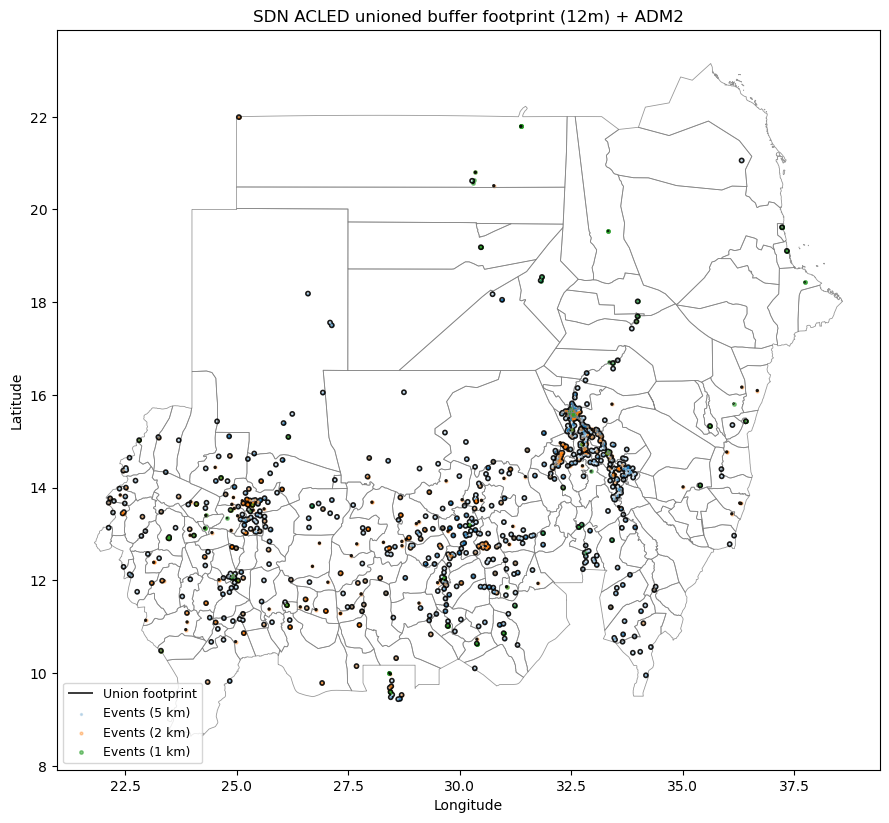

Saved QC: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/qc/SDN_2024-12-01_2025-11-30_m12_acled_violence_footprint_preview.png
Updated: run_metadata.json


In [12]:
# Cell 7 — Buffer events (1/2/5 km), union footprint, and QC plot
# Outputs:
#   - footprint_m: GeoDataFrame (BUFFER_CRS) with single unioned geometry
#   - footprint_wgs84: footprint reprojected to EPSG:4326 (for rasterisation and QC)
#   - Writes VIOL_FOOTPRINT_GPKG
#   - Writes QC_FOOTPRINT_PNG

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# -----------------------
# Buffer in metres
# -----------------------
buffers_m = events_m["buffer_km"].to_numpy(dtype=float) * 1000.0
buffered_geoms = [
    geom.buffer(dist) for geom, dist in zip(events_m.geometry.values, buffers_m)
]

# Union all buffers into one footprint (overlaps collapse to one geometry)
# Note: shapely 2.x has unary_union; geopandas is moving toward union_all() usage.
footprint_geom = unary_union(buffered_geoms)

footprint_m = gpd.GeoDataFrame(
    {"run_id": [RUN_ID], "n_events": [len(events_m)]},
    geometry=[footprint_geom],
    crs=BUFFER_CRS,
)

# Reproject footprint back to WGS84 for rasterisation & QC
footprint_wgs84 = footprint_m.to_crs("EPSG:4326")

# -----------------------
# Save footprint vector (intermediate)
# -----------------------
footprint_wgs84.to_file(VIOL_FOOTPRINT_GPKG, driver="GPKG")
print("Wrote footprint:", VIOL_FOOTPRINT_GPKG)

# -----------------------
# QC plot: ADM2 boundaries + footprint + events
# -----------------------
fig, ax = plt.subplots(figsize=(9, 9))

# ADM2 outlines
admin2_gdf.boundary.plot(ax=ax, linewidth=0.6, edgecolor="grey", alpha=0.8)

# Footprint outline
footprint_wgs84.boundary.plot(
    ax=ax, linewidth=1.2, edgecolor="black", alpha=0.9, label="Union footprint"
)

# Events (plot order: largest first)
for km, ms, a in [(5, 2, 0.20), (2, 4, 0.35), (1, 6, 0.55)]:
    subset = events_wgs84[events_wgs84["buffer_km"] == km]
    if not subset.empty:
        subset.plot(ax=ax, markersize=ms, alpha=a, label=f"Events ({km} km)")

ax.set_title(f"{ISO3} ACLED unioned buffer footprint (12m) + ADM2")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
fig.savefig(QC_FOOTPRINT_PNG, dpi=200)
plt.show()

print("Saved QC:", QC_FOOTPRINT_PNG)

# -----------------------
# Update metadata
# -----------------------
RUN_METADATA["footprint"] = {
    "footprint_gpkg": str(VIOL_FOOTPRINT_GPKG),
    "n_events": int(len(events_m)),
    "buffer_km_counts": acled_df["buffer_km"].value_counts().sort_index().to_dict(),
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)

Wrote mask: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/results/SDN_2024-12-01_2025-11-30_m12_acled_violence_violence_mask.tif
Affected pixels: 5,607,614 / 332,158,376 (1.69%)


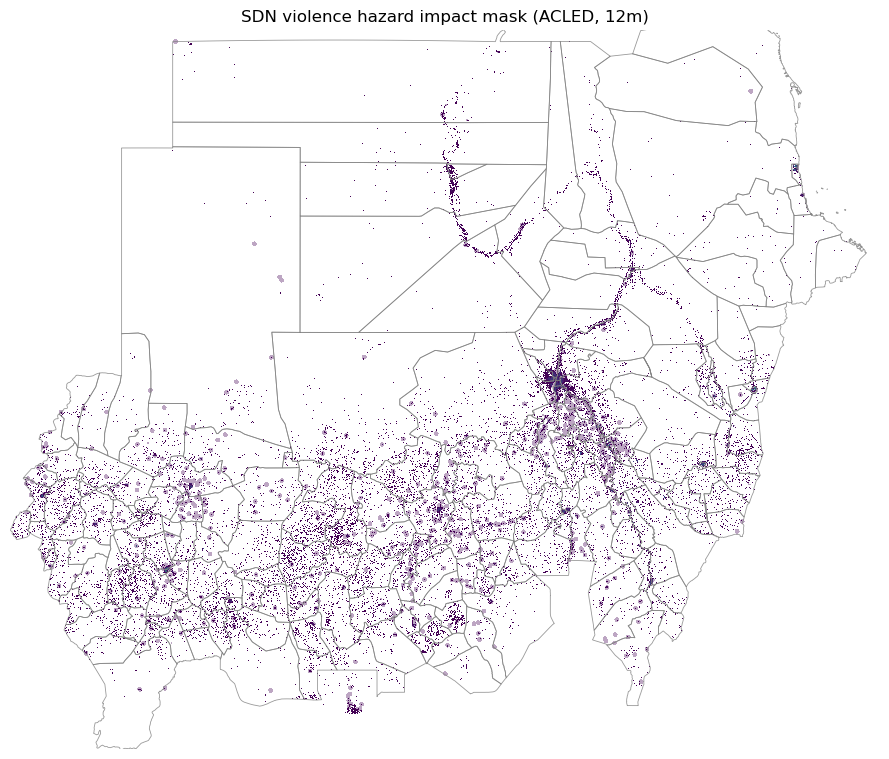

Saved QC: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/qc/SDN_2024-12-01_2025-11-30_m12_acled_violence_mask_overlay.png


In [16]:
# Cell 8 — Rasterise union footprint to binary hazard impact mask + QC
# Outputs:
#   - VIOL_MASK_TIF (uint8, aligned to WorldPop grid)
#   - QC_MASK_PNG (mask overlay on WorldPop)

import numpy as np
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt

# -----------------------
# Rasterise footprint to WorldPop grid
# -----------------------
geom = footprint_wgs84.geometry.iloc[0]
if geom is None or geom.is_empty:
    raise ValueError("Footprint geometry is empty; cannot rasterise.")

mask = rasterize(
    [(geom, 1)],
    out_shape=(WP_HEIGHT, WP_WIDTH),
    transform=WP_TRANSFORM,
    fill=0,
    dtype="uint8",
    all_touched=True,  # keep consistent with other hazard pipelines
)

# -----------------------
# Write mask GeoTIFF
# -----------------------
mask_profile = WP_PROFILE.copy()
mask_profile.update(
    dtype="uint8",
    count=1,
    nodata=0,
    compress="deflate",
    tiled=True,
    blockxsize=512,
    blockysize=512,
)

with rasterio.open(VIOL_MASK_TIF, "w", **mask_profile) as dst:
    dst.write(mask, 1)

print("Wrote mask:", VIOL_MASK_TIF)
print(f"Affected pixels: {int(mask.sum()):,} / {mask.size:,} ({mask.mean()*100:.2f}%)")

# -----------------------
# QC: overlay mask on WorldPop + admin2 boundaries
# -----------------------
with rasterio.open(WORLDPOP_TIF) as src:
    wp = src.read(1).astype("float32")
    nodata = src.nodata
    b = src.bounds  # left, bottom, right, top

if nodata is not None:
    wp[wp == nodata] = np.nan

# Extent in lon/lat for imshow so it aligns with GeoDataFrame coordinates
extent = (b.left, b.right, b.bottom, b.top)

fig, ax = plt.subplots(figsize=(9, 9))

# Base: WorldPop
ax.imshow(wp, interpolation="nearest", extent=extent, origin="upper", zorder=1)

# Mask overlay (same extent!)
ax.imshow(
    np.where(mask == 1, 1, np.nan),
    interpolation="nearest",
    extent=extent,
    origin="upper",
    alpha=0.35,
    zorder=2,
)

# Admin boundaries on top
admin2_gdf.boundary.plot(ax=ax, linewidth=0.6, edgecolor="grey", alpha=0.8, zorder=3)

ax.set_title(f"{ISO3} violence hazard impact mask (ACLED, 12m)")
ax.set_xlim(b.left, b.right)
ax.set_ylim(b.bottom, b.top)
ax.axis("off")

plt.tight_layout()
fig.savefig(QC_MASK_PNG, dpi=200)
plt.show()

print("Saved QC:", QC_MASK_PNG)

In [17]:
# Cell 9 — Population affected raster (WorldPop × mask), nodata-safe + summary
# Outputs:
#   - VIOL_POP_AFFECTED_TIF (float32): population count per pixel where mask==1 else 0
#   - Prints national totals (within raster extent)

import numpy as np
import rasterio

with rasterio.open(WORLDPOP_TIF) as src:
    wp = src.read(1).astype("float64")
    nodata = src.nodata

# Nodata-safe: treat nodata as 0 population for exposure counting
if nodata is not None:
    wp = np.where(wp == nodata, 0.0, wp)

# Apply mask (uint8 0/1) -> affected population per pixel
affected_pop = wp * mask  # float64 in-memory

# Write affected population raster
aff_profile = WP_PROFILE.copy()
aff_profile.update(
    dtype="float32",
    count=1,
    nodata=0,
    compress="deflate",
    tiled=True,
    blockxsize=512,
    blockysize=512,
)

with rasterio.open(VIOL_POP_AFFECTED_TIF, "w", **aff_profile) as dst:
    dst.write(affected_pop.astype("float32"), 1)

# Summary stats
total_pop = float(wp.sum())
pop_affected = float(affected_pop.sum())
pct_affected = (pop_affected / total_pop * 100) if total_pop > 0 else np.nan

print("Wrote affected population raster:", VIOL_POP_AFFECTED_TIF)
print(f"Total population (raster extent): {total_pop:,.0f}")
print(f"Affected population (>=1 event):  {pop_affected:,.0f}")
print(f"% affected:                     {pct_affected:.2f}%")

# Update metadata
RUN_METADATA["population_impact"] = {
    "affected_pop_tif": str(VIOL_POP_AFFECTED_TIF),
    "total_population": total_pop,
    "affected_population": pop_affected,
    "pct_population_affected": pct_affected,
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)

Wrote affected population raster: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/results/SDN_2024-12-01_2025-11-30_m12_acled_violence_violence_pop_affected.tif
Total population (raster extent): 50,849,352
Affected population (>=1 event):  28,676,709
% affected:                     56.40%
Updated: run_metadata.json


In [18]:
# Cell 10 — ADM2 zonal statistics (total pop, affected pop, % affected)
# Outputs:
#   - adm2_stats_df (DataFrame)
#   - ADM2_STATS_CSV written to disk

from rasterstats import zonal_stats
import pandas as pd
import numpy as np

# Ensure admin2 is in the same CRS as the raster (EPSG:4326 here)
if str(admin2_gdf.crs).upper() != "EPSG:4326":
    admin2_zs = admin2_gdf.to_crs("EPSG:4326")
else:
    admin2_zs = admin2_gdf

# Zonal sum of total population
zs_total = zonal_stats(
    admin2_zs,
    str(WORLDPOP_TIF),
    stats=["sum"],
    nodata=WP_NODATA,
    all_touched=True,
)

# Zonal sum of affected population (already nodata-safe with nodata=0)
zs_aff = zonal_stats(
    admin2_zs,
    str(VIOL_POP_AFFECTED_TIF),
    stats=["sum"],
    nodata=0,
    all_touched=True,
)

pop_total = np.array(
    [d["sum"] if d["sum"] is not None else 0.0 for d in zs_total], dtype="float64"
)
pop_aff = np.array(
    [d["sum"] if d["sum"] is not None else 0.0 for d in zs_aff], dtype="float64"
)
pct_aff = np.where(pop_total > 0, pop_aff / pop_total * 100, np.nan)

adm2_stats_df = pd.DataFrame(
    {
        "iso3": ISO3,
        "adm2_pcode": admin2_zs["adm2_pcode"].astype(str).values,
        "pop_total": pop_total,
        "pop_affected": pop_aff,
        "pct_affected": pct_aff,
    }
)

# Basic checks
print("ADM2 rows:", len(adm2_stats_df))
print("Affected pop (sum ADM2):", f"{adm2_stats_df['pop_affected'].sum():,.0f}")
print("Total pop (sum ADM2):   ", f"{adm2_stats_df['pop_total'].sum():,.0f}")

# Write CSV
adm2_stats_df.to_csv(ADM2_STATS_CSV, index=False)
print("Wrote:", ADM2_STATS_CSV)

# Update metadata
RUN_METADATA["adm2_stats"] = {
    "adm2_stats_csv": str(ADM2_STATS_CSV),
    "n_adm2": int(len(adm2_stats_df)),
    "adm2_pop_total_sum": float(adm2_stats_df["pop_total"].sum()),
    "adm2_pop_affected_sum": float(adm2_stats_df["pop_affected"].sum()),
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)

display(adm2_stats_df.head())

ADM2 rows: 188
Affected pop (sum ADM2): 28,715,453
Total pop (sum ADM2):    50,881,206
Wrote: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/results/SDN_2024-12-01_2025-11-30_m12_acled_violence_adm2_stats.csv
Updated: run_metadata.json


,iso3,adm2_pcode,pop_total,pop_affected,pct_affected
0,SDN,SD07090,124524.796875,65658.296875,52.727086
1,SDN,SD16008,138286.609375,8992.876953,6.503071
2,SDN,SD14037,273068.250000,0.000000,0.000000
3,SDN,SD05140,90997.234375,0.000000,0.000000
4,SDN,SD07088,169714.937500,92297.062500,54.383582


ADM2 % affected — summary
  ADM2 units: 188
  Non-null pct: 188
  Min/Median/Max: 0.00% / 28.74% / 100.00%
  Percentiles (5, 25, 75, 95): 0.00%, 6.48%, 55.35%, 87.27%


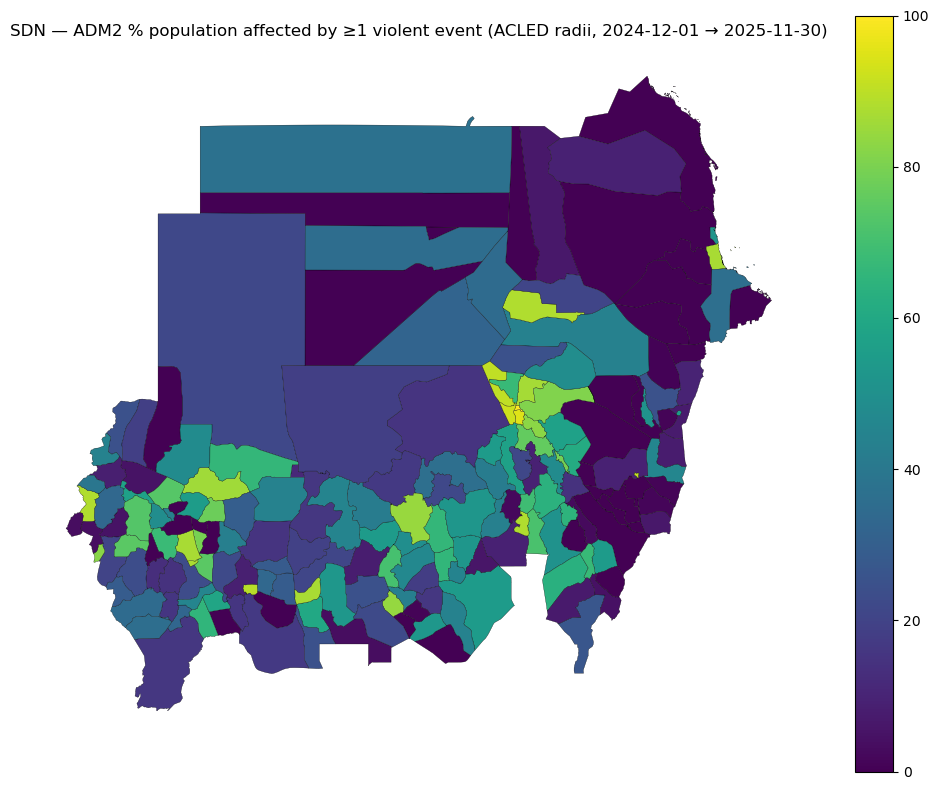

Saved QC: ../outputs/acled_violent_events/SDN_2024-12-01_2025-11-30_m12_acled_violence/qc/SDN_2024-12-01_2025-11-30_m12_acled_violence_adm2_pct_affected.png
Updated: run_metadata.json


In [19]:
# Cell 11 — Final QC: join ADM2 stats + choropleth map + distribution checks
# Outputs:
#   - admin2_qc_gdf: admin2 geometries with pop stats joined
#   - QC_ADM2_MAP_PNG written to disk

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Join stats back to admin2
admin2_qc_gdf = admin2_gdf.merge(adm2_stats_df, on=["iso3", "adm2_pcode"], how="left")

# Fill missing stats as 0 where appropriate (shouldn't happen, but keeps plots stable)
admin2_qc_gdf["pop_total"] = admin2_qc_gdf["pop_total"].fillna(0.0)
admin2_qc_gdf["pop_affected"] = admin2_qc_gdf["pop_affected"].fillna(0.0)
admin2_qc_gdf["pct_affected"] = np.where(
    admin2_qc_gdf["pop_total"] > 0,
    admin2_qc_gdf["pop_affected"] / admin2_qc_gdf["pop_total"] * 100,
    np.nan,
)

# Distribution checks
pct = admin2_qc_gdf["pct_affected"].dropna()
print("ADM2 % affected — summary")
print(f"  ADM2 units: {len(admin2_qc_gdf):,}")
print(f"  Non-null pct: {len(pct):,}")
print(f"  Min/Median/Max: {pct.min():.2f}% / {pct.median():.2f}% / {pct.max():.2f}%")
print(
    "  Percentiles (5, 25, 75, 95):",
    ", ".join([f"{p:.2f}%" for p in np.percentile(pct, [5, 25, 75, 95])]),
)

# Choropleth QC map (no fixed colours/styles; default geopandas colormap)
fig, ax = plt.subplots(figsize=(10, 8))
admin2_qc_gdf.plot(
    column="pct_affected",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

ax.set_title(
    f"{ISO3} — ADM2 % population affected by ≥1 violent event (ACLED radii, {WINDOW_START_DATE} → {WINDOW_END_DATE})"
)
ax.axis("off")

plt.tight_layout()
fig.savefig(QC_ADM2_MAP_PNG, dpi=200)
plt.show()

print("Saved QC:", QC_ADM2_MAP_PNG)

# Update metadata
RUN_METADATA["qc_outputs"] = {
    "qc_events_png": str(QC_EVENTS_PNG),
    "qc_footprint_png": str(QC_FOOTPRINT_PNG),
    "qc_mask_png": str(QC_MASK_PNG),
    "qc_adm2_map_png": str(QC_ADM2_MAP_PNG),
}

with open(RUN_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_METADATA, f, indent=2)

print("Updated:", RUN_METADATA_PATH.name)